In [18]:
import pandas as pd

# 2022년도 데이터
# 2022년 전체데이터, ratings 기준 내림차순 105개 자료

In [19]:
# 2022년도 전체데이터에서 title genre age ratings
df1 = pd.read_csv("result_2022.csv")
df1

,Unnamed: 0,title,genre,age,ratings
0,0,순정빌런,"스토리, 로맨스",12세 이용가,9.99
1,1,계룡선녀전,"스토리, 드라마",전체연령가,9.98
2,2,악마와 계약연애,"스토리, 로맨스",12세 이용가,9.98
3,3,구름의 이동속도,"에피소드, 드라마",전체연령가,9.98
4,4,웰캄투실버라이프,"에피소드, 일상",전체연령가,9.98
...,...,...,...,...,...
100,100,환상적인 소년,"스토리, 판타지",전체연령가,9.98
101,101,달이 없는 나라,"스토리, 로맨스",전체연령가,9.97
102,102,환상연가,"스토리, 로맨스",전체연령가,9.97
103,103,달콤살벌한 부부,"스토리, 로맨스",15세 이용가,9.97


In [8]:
# 데이터 타입 확인
df1.dtypes

Unnamed: 0      int64
title          object
genre          object
age            object
ratings       float64
dtype: object

In [9]:
# 비어있는값 확인
df1.isnull().sum()

Unnamed: 0    0
title         0
genre         0
age           0
ratings       0
dtype: int64

In [10]:
# 중복된 값 확인
df1.duplicated().sum()

np.int64(0)

In [20]:
# 원본데이터에 대한 복사본(df1_copy) 생성
df1_copy = df1
df1_copy

,Unnamed: 0,title,genre,age,ratings
0,0,순정빌런,"스토리, 로맨스",12세 이용가,9.99
1,1,계룡선녀전,"스토리, 드라마",전체연령가,9.98
2,2,악마와 계약연애,"스토리, 로맨스",12세 이용가,9.98
3,3,구름의 이동속도,"에피소드, 드라마",전체연령가,9.98
4,4,웰캄투실버라이프,"에피소드, 일상",전체연령가,9.98
...,...,...,...,...,...
100,100,환상적인 소년,"스토리, 판타지",전체연령가,9.98
101,101,달이 없는 나라,"스토리, 로맨스",전체연령가,9.97
102,102,환상연가,"스토리, 로맨스",전체연령가,9.97
103,103,달콤살벌한 부부,"스토리, 로맨스",15세 이용가,9.97


In [21]:
# genre 컬럼에서 "연재형식,장르"
# -> series컬럼 "연재형식", genre컬럼 "장르" 로 분류

split_genre = df1_copy['genre'].str.split(',', n=1, expand=True)

df1_copy['series'] = split_genre[0].str.strip()
df1_copy['genre'] = split_genre[1].str.strip()

df1_copy.columns

Index(['Unnamed: 0', 'title', 'genre', 'age', 'ratings', 'series'], dtype='object')

In [22]:
df1_copy

,Unnamed: 0,title,genre,age,ratings,series
0,0,순정빌런,로맨스,12세 이용가,9.99,스토리
1,1,계룡선녀전,드라마,전체연령가,9.98,스토리
2,2,악마와 계약연애,로맨스,12세 이용가,9.98,스토리
3,3,구름의 이동속도,드라마,전체연령가,9.98,에피소드
4,4,웰캄투실버라이프,일상,전체연령가,9.98,에피소드
...,...,...,...,...,...,...
100,100,환상적인 소년,판타지,전체연령가,9.98,스토리
101,101,달이 없는 나라,로맨스,전체연령가,9.97,스토리
102,102,환상연가,로맨스,전체연령가,9.97,스토리
103,103,달콤살벌한 부부,로맨스,15세 이용가,9.97,스토리


In [23]:
# genre로 그룹화 시켰을때 갯수
df1_copy.groupby('genre').size()

genre
감성        7
개그        9
드라마      28
로맨스      30
무협/사극     1
스릴러       5
액션        3
일상        3
판타지      19
dtype: int64

In [25]:
# series로 그룹화 시켰을때 개수
df1_copy.groupby('series').size()

series
스토리     88
에피소드    14
옴니버스     3
dtype: int64

In [26]:
# age로 그룹화 시켰을때 개수
df1_copy.groupby('age').size()

age
-           1
12세 이용가    20
15세 이용가    16
18세 이용가     3
전체연령가      65
dtype: int64

In [27]:
df1_copy[df1_copy['age'] == '-']

,Unnamed: 0,title,genre,age,ratings,series
48,48,필살VS로맨스,개그,-,9.98,스토리


In [28]:
# age 컬럼에 "-" 표기가 들어간것 "전체연령가"로 변경
df1_copy['age'] = df1_copy['age'].replace('-', '전체연령가')
df1_copy.groupby('age').size()

age
12세 이용가    20
15세 이용가    16
18세 이용가     3
전체연령가      66
dtype: int64

# 2026년도 데이터
# 요일별(평점순) 상위15개, 105개 자료

In [3]:
df2 = pd.read_csv("result_copy.csv")
df2

,Unnamed: 0,title,genre,age,week,ratings
0,0,토마토가 돼라!,"스토리, 로맨스",15세 이용가,월,9.98
1,1,똑 닮은 딸,"스토리, 스릴러",15세 이용가,월,9.98
2,2,왕과의 야행,"스토리, 로맨스",18세 이용가,월,9.97
3,3,피폐물을 힐링물로 만드는 방법,"스토리, 로맨스",15세 이용가,월,9.97
4,4,대공비가 체질입니다,"스토리, 로맨스",15세 이용가,월,9.97
...,...,...,...,...,...,...
100,100,고백대리,"에피소드, 로맨스",12세 이용가,일,9.96
101,101,아카데미에 위장취업당했다,"스토리, 판타지",12세 이용가,일,9.96
102,102,찐한 고백,"에피소드, 로맨스",12세 이용가,일,9.96
103,103,육아일기,"에피소드, 일상",전체연령가,일,9.96


In [4]:
# ratings 컬럼, 내림차순정렬
df2_sorted = df2.sort_values(by='ratings', ascending=False)
df2_sorted

,Unnamed: 0,title,genre,age,week,ratings
0,0,토마토가 돼라!,"스토리, 로맨스",15세 이용가,월,9.98
17,17,전리품 공작부인,"스토리, 로맨스",전체연령가,화,9.98
47,47,"풍작이에요, 마왕님!","스토리, 판타지",전체연령가,목,9.98
46,46,삼이는 재생한다,"스토리, 로맨스",12세 이용가,목,9.98
45,45,소심한 호랭이 코코,"에피소드, 일상",전체연령가,목,9.98
...,...,...,...,...,...,...
72,72,소곤소곤2,"에피소드, 드라마",15세 이용가,금,9.96
73,73,"언니, 이번 생엔 내가 왕비야","스토리, 로맨스",15세 이용가,금,9.96
74,74,문제적 왕자님,"스토리, 로맨스",15세 이용가,금,9.96
43,43,잠겨죽어도,"스토리, 스릴러",15세 이용가,수,9.96


In [11]:
df2.duplicated().sum()

np.int64(0)

In [30]:
# ratings컬럼 내림차순정렬해 df2원본에 넣기
df2 = df2_sorted
df2

,Unnamed: 0,title,genre,age,week,ratings
0,0,토마토가 돼라!,"스토리, 로맨스",15세 이용가,월,9.98
17,17,전리품 공작부인,"스토리, 로맨스",전체연령가,화,9.98
47,47,"풍작이에요, 마왕님!","스토리, 판타지",전체연령가,목,9.98
46,46,삼이는 재생한다,"스토리, 로맨스",12세 이용가,목,9.98
45,45,소심한 호랭이 코코,"에피소드, 일상",전체연령가,목,9.98
...,...,...,...,...,...,...
72,72,소곤소곤2,"에피소드, 드라마",15세 이용가,금,9.96
73,73,"언니, 이번 생엔 내가 왕비야","스토리, 로맨스",15세 이용가,금,9.96
74,74,문제적 왕자님,"스토리, 로맨스",15세 이용가,금,9.96
43,43,잠겨죽어도,"스토리, 스릴러",15세 이용가,수,9.96


In [31]:
# 원본데이터에 대한 복사본(df2_copy) 생성
df2_copy = df2
df2_copy

,Unnamed: 0,title,genre,age,week,ratings
0,0,토마토가 돼라!,"스토리, 로맨스",15세 이용가,월,9.98
17,17,전리품 공작부인,"스토리, 로맨스",전체연령가,화,9.98
47,47,"풍작이에요, 마왕님!","스토리, 판타지",전체연령가,목,9.98
46,46,삼이는 재생한다,"스토리, 로맨스",12세 이용가,목,9.98
45,45,소심한 호랭이 코코,"에피소드, 일상",전체연령가,목,9.98
...,...,...,...,...,...,...
72,72,소곤소곤2,"에피소드, 드라마",15세 이용가,금,9.96
73,73,"언니, 이번 생엔 내가 왕비야","스토리, 로맨스",15세 이용가,금,9.96
74,74,문제적 왕자님,"스토리, 로맨스",15세 이용가,금,9.96
43,43,잠겨죽어도,"스토리, 스릴러",15세 이용가,수,9.96


In [32]:
# genre 컬럼에서 "연재형식,장르"
# -> series컬럼 "연재형식", genre컬럼 "장르" 로 분류

split_genre = df2_copy['genre'].str.split(',', n=1, expand=True)

df2_copy['series'] = split_genre[0].str.strip()
df2_copy['genre'] = split_genre[1].str.strip()

df2_copy

,Unnamed: 0,title,genre,age,week,ratings,series
0,0,토마토가 돼라!,로맨스,15세 이용가,월,9.98,스토리
17,17,전리품 공작부인,로맨스,전체연령가,화,9.98,스토리
47,47,"풍작이에요, 마왕님!",판타지,전체연령가,목,9.98,스토리
46,46,삼이는 재생한다,로맨스,12세 이용가,목,9.98,스토리
45,45,소심한 호랭이 코코,일상,전체연령가,목,9.98,에피소드
...,...,...,...,...,...,...,...
72,72,소곤소곤2,드라마,15세 이용가,금,9.96,에피소드
73,73,"언니, 이번 생엔 내가 왕비야",로맨스,15세 이용가,금,9.96,스토리
74,74,문제적 왕자님,로맨스,15세 이용가,금,9.96,스토리
43,43,잠겨죽어도,스릴러,15세 이용가,수,9.96,스토리


In [33]:
# genre로 그룹화 시켰을때 갯수
df2_copy.groupby('genre').size()

genre
감성        5
개그        2
드라마      10
로맨스      42
무협/사극     3
스릴러       5
액션        2
일상       11
판타지      25
dtype: int64

In [34]:
# series로 그룹화 시켰을때 개수
df2_copy.groupby('series').size()

series
스토리     68
에피소드    35
옴니버스     2
dtype: int64

In [35]:
df2_copy.groupby('age').size()

age
12세 이용가    22
15세 이용가    43
18세 이용가     1
전체연령가      39
dtype: int64

In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### genre로 비교

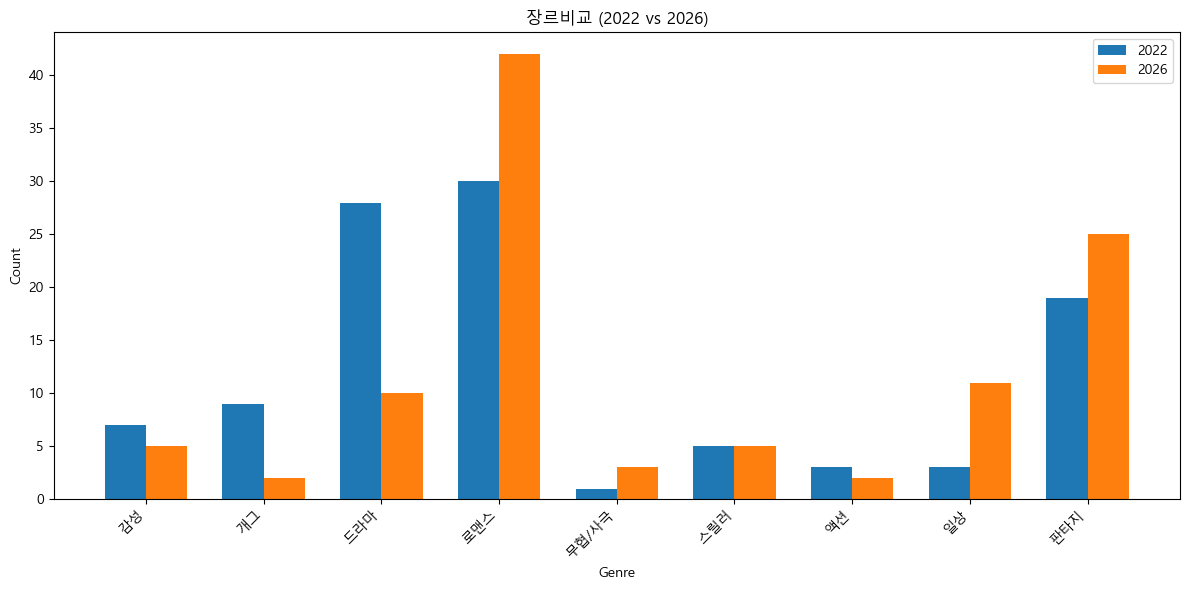

In [41]:

# 1️⃣ 각 데이터프레임에서 집계
g1 = df1_copy['genre'].value_counts()
g2 = df2_copy['genre'].value_counts()

# 2️⃣ 공통 genre 기준으로 정렬
genres = sorted(set(g1.index) | set(g2.index))

v1 = [g1.get(g, 0) for g in genres]
v2 = [g2.get(g, 0) for g in genres]

# 3️⃣ 막대 위치 설정
x = np.arange(len(genres))
width = 0.35

# 4️⃣ 그래프
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, v1, width, label='2022')
plt.bar(x + width/2, v2, width, label='2026')

# 5️⃣ 옵션
plt.xticks(x, genres, rotation=45, ha='right')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('장르비교 (2022 vs 2026)')
plt.legend()

plt.tight_layout()
plt.show()


### series로 비교

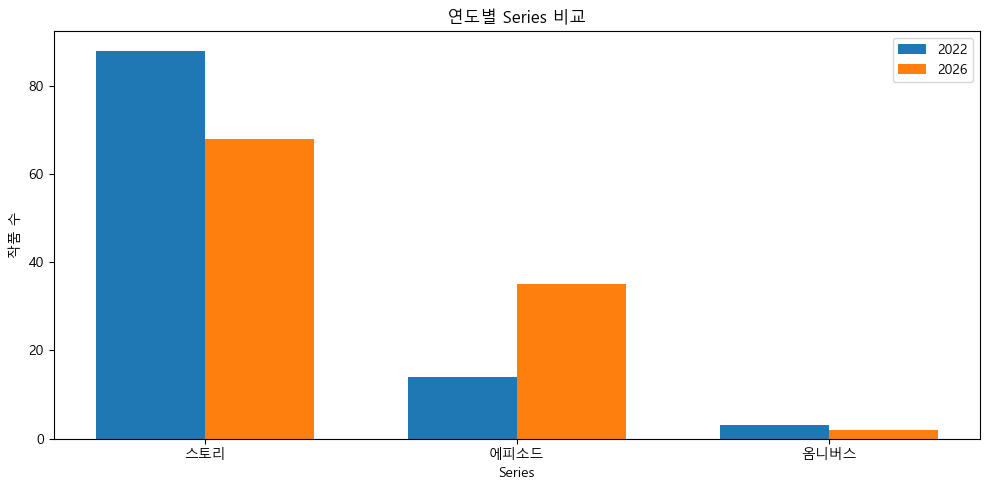

In [42]:
# 집계
s1 = df1_copy['series'].value_counts()
s2 = df2_copy['series'].value_counts()

# 공통 series 목록
series_list = sorted(set(s1.index) | set(s2.index))

v1 = [s1.get(s, 0) for s in series_list]
v2 = [s2.get(s, 0) for s in series_list]

# 막대 위치
x = np.arange(len(series_list))
width = 0.35

# 그래프
plt.figure(figsize=(10, 5))
plt.bar(x - width/2, v1, width, label='2022')
plt.bar(x + width/2, v2, width, label='2026')

plt.xticks(x, series_list)
plt.xlabel('Series')
plt.ylabel('작품 수')
plt.title('연도별 Series 비교')
plt.legend()

plt.tight_layout()
plt.show()


### age로 비교

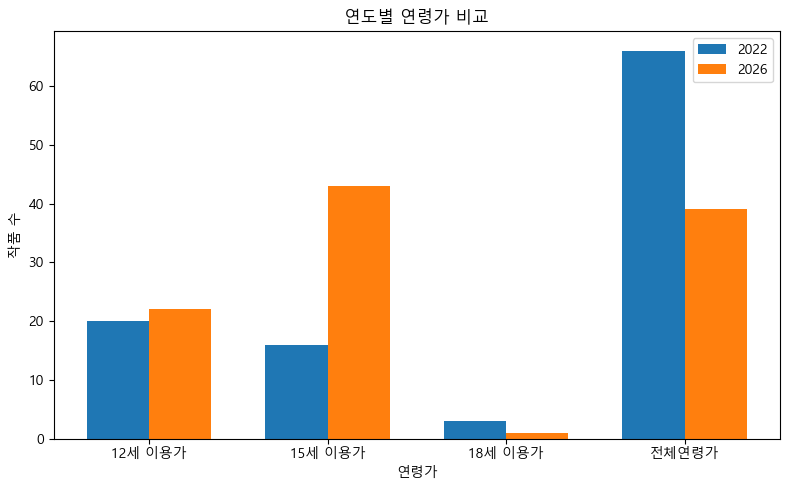

In [43]:
# 집계
a1 = df1_copy['age'].value_counts()
a2 = df2_copy['age'].value_counts()

# 공통 age 목록
age_list = sorted(set(a1.index) | set(a2.index))

v1 = [a1.get(a, 0) for a in age_list]
v2 = [a2.get(a, 0) for a in age_list]

# 막대 위치
x = np.arange(len(age_list))
width = 0.35

# 그래프
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, v1, width, label='2022')
plt.bar(x + width/2, v2, width, label='2026')

plt.xticks(x, age_list)
plt.xlabel('연령가')
plt.ylabel('작품 수')
plt.title('연도별 연령가 비교')
plt.legend()

plt.tight_layout()
plt.show()
